### 梯度下降法实现

梯度下降法求解：y=9.7966+5.4160x1+12.5843x2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码问题
plt.rcParams["axes.unicode_minus"] = False  # 使负号正常显示

# 二元函数表达式
def f1(x,y):
    return 9.7966 + 5.4160 * x + 12.5843 * y
# 对x求偏导
def hx1(x,y):
    return 5.4160
# 对y求偏导
def hy1(x,y):
    return 12.5843

D:\Anaconda\AnacondaWork\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\Anaconda\AnacondaWork\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
D:\Anaconda\AnacondaWork\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [3]:
# 初始值
x = 1
y = 1
# 存放迭代的点坐标及对应函数值列表
GD_X = []
GD_Y = []
GD_Z = []
# 对应函数值的变化量及真实值
z_current = f1(x,y)
z_change = z_current
# 学习率
alpha = 0.05
# 迭代次数
item_num = 0

GD_X.append(x)
GD_Y.append(y)
GD_Z.append(z_current)

In [4]:
# 迭代过程
while z_change>1e-10 and item_num<100:
    item_num += 1
    # 改变x和y的值
    x = x - alpha * hx1(x,y)
    y = y - alpha * hx2(x,y)
    tmp = z_current
    z_current = f1(x,y)
    z_change = np.abs(tmp - z_current)
    # 存储当前情况下对应函数值
    GD_X.append(x)
    GD_Y.append(y)
    GD_Z.append(z_current)
    
print(u'最终结果：(%.5f,%.5f,%.5f)'%(x,y,z_current))
print("迭代次数：",item_num)
print(GD_X)
print(GD_Y)
print(GD_Z)

NameError: name 'hx2' is not defined

In [ ]:
# 作图
X = np.arange(-4,4.5,0.05)
Y = np.arange(-4,4.5,0.05)
X,Y = np.meshgrid(X,Y)

Z = np.array(list(map(lambda t:f1(t[0],t[1]),zip(X.flatten(),Y.flatten()))))
Z.shape = X.shape

fig = plt.figure(facecolor='w')
ax = Axes3D(fig)
fig.add_axes(ax)
ax.plot_surface(X,Y,Z,rstride=1,cstride=1,cmap=plt.cm.jet)
ax.plot(GD_X,GD_Y,GD_Z,'ro--')

ax.set_title('求解函数 y = 9.7966 + 5.4160 * x1 + 12.5843 * x2 最小值')
plt.show()

### 线性回归实现

尝试探讨价格水平对GDP的影响来说明如何使用多元回归分析

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码问题
plt.rcParams["axes.unicode_minus"] = False  # 使负号正常显示

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [6]:
def maxminscaler(x):
    data = x
    for i in data.columns:
        maxi = data[i].max()
        mini = data[i].min()
        data[i] = (data[i]-mini)/(maxi-mini)
    return data

In [7]:
data = pd.read_excel('Penn World Table.xlsx')
# rgdp:GDP  pl_c:居民消费价格水平  pl_i:资本存量水平  pl_g:政府采购价格水平  pl_x:出口价格水平  pl_m:进口价格水平  pl_k:资本存量水平
data

,countrycode,country,currency_unit,year,rgdpe,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k
0,AGO,Angola,Kwanza,2007,58131.746094,1.253990,0.738191,1.076301,0.650072,0.764166,0.617699
1,AGO,Angola,Kwanza,2008,67472.859375,1.418632,0.938361,1.352946,0.774891,0.937404,0.777646
2,AGO,Angola,Kwanza,2009,59256.636719,1.681747,0.786687,1.105007,0.829843,1.190549,0.657191
3,AGO,Angola,Kwanza,2010,76151.132812,1.195477,0.843884,1.161518,0.920334,0.961341,0.706732
4,AGO,Angola,Kwanza,2011,82680.945312,1.294905,1.048095,1.460608,1.194767,1.239069,0.868282
...,...,...,...,...,...,...,...,...,...,...,...
830,ZWE,Zimbabwe,Zimbabwe Dollar,2007,45666.082031,0.155326,0.096808,0.030871,0.836226,0.704391,1.322423
831,ZWE,Zimbabwe,Zimbabwe Dollar,2008,35789.878906,0.187243,0.075830,0.017838,0.812021,0.899782,0.920607
832,ZWE,Zimbabwe,Zimbabwe Dollar,2009,49294.878906,0.112196,0.211507,0.153393,0.274833,0.375842,3.617210
833,ZWE,Zimbabwe,Zimbabwe Dollar,2010,51259.152344,0.123692,0.237427,0.168766,0.298547,0.407374,4.071371


<AxesSubplot: >

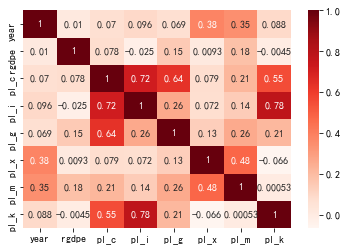

In [8]:
sns.heatmap(data.corr(),cmap="Reds",annot=True)

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0, 0.5, 'rgdpe'),
  Text(0, 1.5, 'pl_c'),
  Text(0, 2.5, 'pl_i'),
  Text(0, 3.5, 'pl_g'),
  Text(0, 4.5, 'pl_x'),
  Text(0, 5.5, 'pl_m'),
  Text(0, 6.5, 'pl_k')])

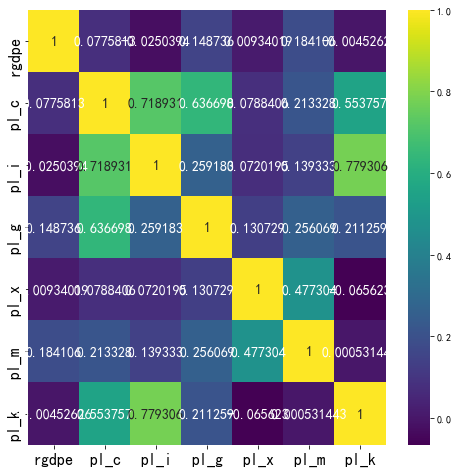

In [9]:
data = pd.read_excel('Penn World Table.xlsx')
data = data[['rgdpe','pl_c','pl_i','pl_g','pl_x','pl_m','pl_k']]
data = maxminscaler(data)
plt.subplots(figsize = (8,8))
sns.heatmap(data.corr(),fmt='g',cmap='viridis',annot=True,annot_kws={"fontsize":14})  # 通过热力图发现有多重共线性
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

In [73]:
# 开始导入数据集，训练
y_data = data.rgdpe
x_data = data[['pl_c','pl_i','pl_g','pl_x','pl_m','pl_k']]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test  = train_test_split(x_data,y_data,test_size=0.9,random_state=123456)

# x_train = x_data[0:500]
# x_test = x_data[500:550]
# y_train = y_data[0:500]
# y_test = y_data[500:550]
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
print(x_train.shape)
print(y_train.shape)

(83, 6)
(83, 1)


In [74]:
x_test.shape

(752, 6)

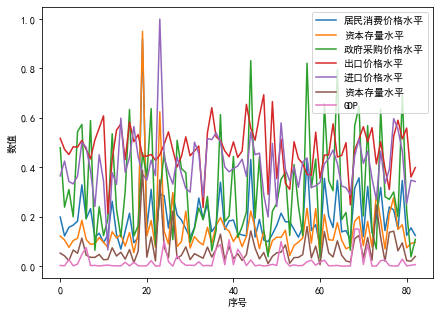

In [75]:
# 探索性数据分析
plt.figure(figsize=(7,5))
plt.plot(x_train[:,0],label='居民消费价格水平')
plt.plot(x_train[:,1],label='资本存量水平')
plt.plot(x_train[:,2],label='政府采购价格水平')
plt.plot(x_train[:,3],label='出口价格水平')
plt.plot(x_train[:,4],label='进口价格水平')
plt.plot(x_train[:,5],label='资本存量水平')
plt.plot(y_train,label='GDP')
plt.xlabel('序号')
plt.ylabel('数值')
# plt.title('空调耗电量')
plt.legend()
plt.show()

In [76]:
# 初始化模型参数
def initialize_params(dims): # m*1
    w = np.zeros((dims,1))
    b = 1
    return w,b

In [77]:
'''
    输入：
    x：输入变量矩阵 n*m
    y：输出标签向量 n*1
    w：变量参数权重矩阵 m*1
    b：偏差项 N
    输入：
    y_hat：线性模型预测输出
    loss：均方损失值
    dw：权重参数一阶偏导
    db：偏差项一阶偏导
'''
# 定义线性回归模型主体
def linear_loss(x,y,w,b):  # 注意x,y的选取 x:15*2, y:15*1, w:2*1, b是正数
    num_train = x.shape[0]  # 获取样本数
    num_feature = x.shape[1]  # 获取特征数
    y_hat = np.dot(x,w)+b  # 线性回归预测值 n*m,m*1=n*1
    loss = np.sum((y_hat-y)**2)/num_train  # n*1 计算预测值与实际标签之间的均方损失
    dw = np.dot(x.T,(y_hat-y))/num_train  # m*1 基于均方差损失对权重系数的一阶梯度
    db = np.sum((y_hat-y))/num_train  # N基于均方差损失对偏移量
    return y_hat,loss,dw,db

In [78]:
# 定义线性回归模型的训练过程
def linear_train(x,y,learning_rate,epochs):
    loss_his = []
    w,b = initialize_params(x.shape[1])
    for i in range(1,epochs):
        # 计算当前迭代的预测值，均方损失和梯度
        y_hat,loss,dw,db = linear_loss(x,y,w,b)
        # 基于梯度下降法的参数更新
        w = w - learning_rate * dw
        b = b - learning_rate * db
        # 记录当前迭代的损失
        loss_his.append(loss)
        params = {'w':w,'b':b}
        grads = {'dw':dw,'db':db}
    return loss_his,params,grads

In [79]:
def predict(x,params):
    w = params['w']
    b = params['b']
    y_pred = np.dot(x,w) + b
    return y_pred

In [80]:
def r2_score(y_test,y_pred):
    y_avg = np.mean(y_test)
    ss_tot = np.sum((y_test - y_avg) ** 2)
    ss_res = np.sum((y_test - y_pred) ** 2)
    r2 = 1 - (ss_res/ss_tot)
    return r2

In [81]:
print(x)

0.7292


In [82]:
loss_his,params,grads = linear_train(x_train,y_train,0.01,10000)
print(params['w'])
print(min(loss_his))

[[-0.00995895]
 [-0.00956753]
 [ 0.05684082]
 [-0.17721883]
 [-0.02125825]
 [ 0.02041967]]
0.0013018958017999847


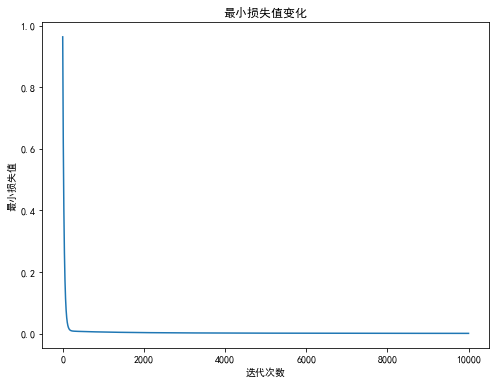

In [83]:
# 绘制损失率图
plt.figure(figsize=(8,6))
plt.plot(loss_his)
plt.xlabel('迭代次数')
plt.ylabel('最小损失值')
plt.title('最小损失值变化')
plt.show()

[[ 1.62436118e-02]
 [ 3.66667633e-02]
 [-5.41255184e-03]
 [ 1.41896100e-02]
 [ 1.79221001e-02]
 [ 3.00610699e-02]
 [ 2.50624586e-03]
 [-4.41556028e-03]
 [-1.81744778e-02]
 [ 2.64892202e-02]
 [ 1.85364785e-02]
 [ 3.96277074e-02]
 [ 2.71194797e-02]
 [-2.28318336e-02]
 [ 4.82100996e-02]
 [ 2.86960004e-02]
 [ 1.03317119e-02]
 [ 2.82415565e-03]
 [ 8.46707576e-03]
 [ 3.42962097e-02]
 [ 6.31209751e-03]
 [ 2.71381143e-02]
 [ 4.88265641e-02]
 [ 2.91710837e-02]
 [-2.22050365e-02]
 [ 3.31796127e-03]
 [ 4.18612612e-02]
 [ 8.82749383e-03]
 [ 2.70485843e-02]
 [-2.17401352e-02]
 [ 7.69623543e-04]
 [ 2.75567879e-02]
 [ 2.47475011e-02]
 [ 1.26096090e-02]
 [ 3.75865512e-02]
 [ 1.81069948e-02]
 [ 2.18528539e-02]
 [ 1.08528001e-02]
 [ 2.87231971e-02]
 [ 3.04468428e-02]
 [ 1.79335822e-03]
 [ 2.32388243e-02]
 [ 1.07299081e-02]
 [ 2.52123768e-02]
 [ 1.44186753e-02]
 [ 3.07108593e-02]
 [ 2.73129334e-02]
 [ 1.35906586e-02]
 [ 4.22652878e-02]
 [ 3.23517074e-02]
 [-2.44848140e-02]
 [ 4.24284372e-03]
 [ 3.5038028

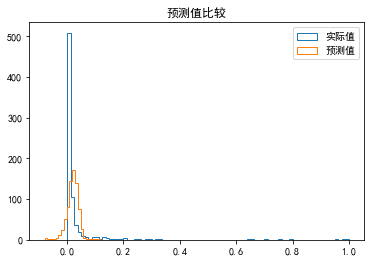

In [95]:
y_pred = predict(x_test,params)
print(y_pred)
print(y_test)
plt.figure()
plt.title('预测值比较')
plt.hist(y_test,label = '实际值',bins = 80,histtype='step')

plt.hist(y_pred,label = '预测值',bins = 20,histtype='step')
plt.legend()
plt.show()

In [85]:
y_pred = y_pred.reshape(820,)
y_test = y_test.reshape(820,)
sns.lineplot(x=y_pred,y=y_test)

ValueError: cannot reshape array of size 752 into shape (820,)